In [1]:
# Load the data we saved in Block 1 and take a first look.
# We use relative paths from the notebooks/ folder up to data/raw/.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make the plots a bit cleaner and consistent across the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sensor_readings = pd.read_csv("../data/raw/secom_features.csv")
labels = pd.read_csv("../data/raw/secom_targets.csv", parse_dates=["timestamp"])

print("sensor_readings:", sensor_readings.shape)
print("labels:        ", labels.shape)
labels.head()

sensor_readings: (1567, 590)
labels:         (1567, 2)


,label,timestamp
0,-1,2008-07-19 11:55:00
1,-1,2008-07-19 12:32:00
2,1,2008-07-19 13:17:00
3,-1,2008-07-19 14:43:00
4,-1,2008-07-19 15:22:00


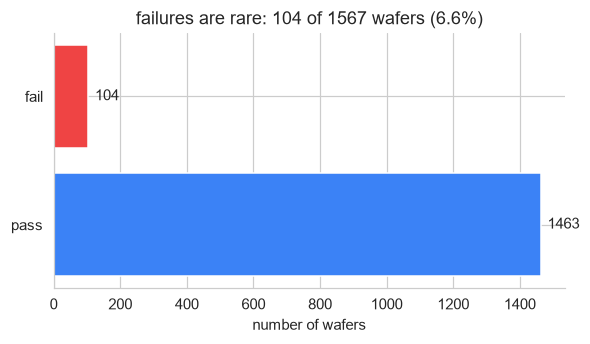

In [2]:
# How balanced is the dataset? Already know the answer from Block 1, but
# seeing it as a plot makes it stick: failures are rare. This is the central
# challenge of the whole project.

fail_count = (labels["label"] == 1).sum()
pass_count = (labels["label"] == -1).sum()

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["pass", "fail"], [pass_count, fail_count], color=["#3b82f6", "#ef4444"])
ax.set_xlabel("number of wafers")
ax.set_title(f"failures are rare: {fail_count} of {len(labels)} wafers ({fail_count / len(labels) * 100:.1f}%)")
for i, count in enumerate([pass_count, fail_count]):
    ax.text(count + 20, i, str(count), va="center")
plt.show()

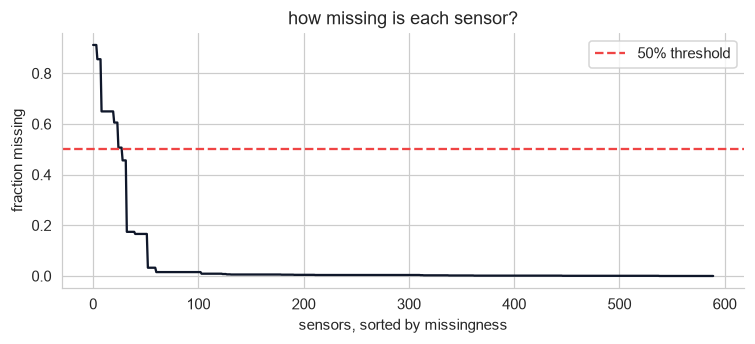

sensors more than 50% missing: 28
sensors more than 25% missing: 32
sensors with zero missing:     52


In [3]:
# How many missing values per sensor? If a sensor is missing more than half
# its readings, it's probably not safe to use — we'd be imputing more than we
# observe. We'll mark a threshold and use it later when cleaning.

missing_per_sensor = sensor_readings.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(len(missing_per_sensor)), missing_per_sensor.values, color="#0f172a")
ax.axhline(0.5, color="#ef4444", linestyle="--", label="50% threshold")
ax.set_xlabel("sensors, sorted by missingness")
ax.set_ylabel("fraction missing")
ax.set_title("how missing is each sensor?")
ax.legend()
plt.show()

n_above_half = (missing_per_sensor > 0.5).sum()
n_above_quarter = (missing_per_sensor > 0.25).sum()
print(f"sensors more than 50% missing: {n_above_half}")
print(f"sensors more than 25% missing: {n_above_quarter}")
print(f"sensors with zero missing:     {(missing_per_sensor == 0).sum()}")

In [4]:
# A "dead" sensor is one whose values barely vary across all wafers.
# We use the standard deviation, ignoring missing values. Anything with
# std below a tiny threshold is effectively constant and should be dropped.

sensor_stds = sensor_readings.std(numeric_only=True)
near_constant = sensor_stds[sensor_stds < 1e-6]

print(f"sensors with near-zero std: {len(near_constant)}")
print("first few:")
print(near_constant.head(10))

sensors with near-zero std: 116
first few:
sensor_5      0.0
sensor_13     0.0
sensor_42     0.0
sensor_49     0.0
sensor_52     0.0
sensor_69     0.0
sensor_97     0.0
sensor_141    0.0
sensor_149    0.0
sensor_178    0.0
dtype: float64


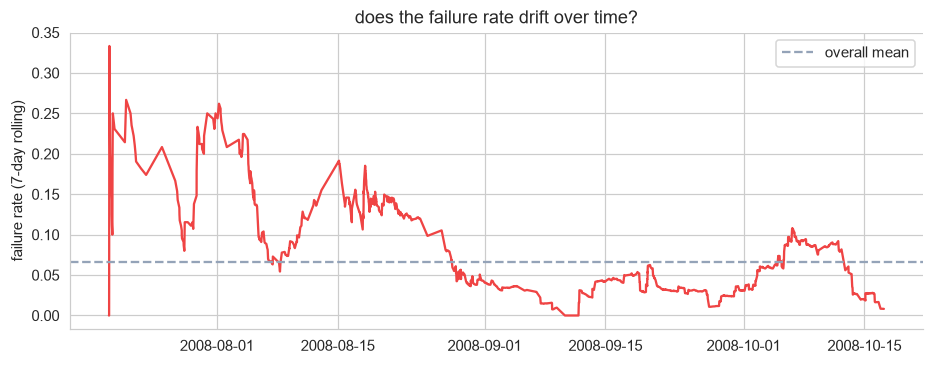

In [5]:
# If the production process is stable, the failure rate should be roughly
# constant over time. If it isn't, that's exactly the kind of drift our
# monitoring system needs to catch. Roll a 7-day window so we smooth out
# day-to-day noise but still see longer trends.

over_time = labels.copy()
over_time["is_failure"] = (over_time["label"] == 1).astype(int)
over_time = over_time.sort_values("timestamp").set_index("timestamp")

rolling_rate = over_time["is_failure"].rolling("7D").mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rolling_rate.index, rolling_rate.values, color="#ef4444")
ax.axhline(over_time["is_failure"].mean(), color="#94a3b8", linestyle="--", label="overall mean")
ax.set_ylabel("failure rate (7-day rolling)")
ax.set_title("does the failure rate drift over time?")
ax.legend()
plt.show()

In [6]:
# Split chronologically: earliest 60% for training, next 20% for validation,
# final 20% for the production-like test set. This matches how the model
# would be deployed in real life — train on the past, predict the future.

combined = sensor_readings.copy()
combined["timestamp"] = labels["timestamp"].values
combined["label"]     = labels["label"].values
combined = combined.sort_values("timestamp").reset_index(drop=True)

n = len(combined)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train = combined.iloc[:train_end]
val   = combined.iloc[train_end:val_end]
test  = combined.iloc[val_end:]

for name, part in [("train", train), ("val", val), ("test", test)]:
    fail_pct = (part["label"] == 1).mean() * 100
    print(f"{name:5s}  {len(part):>5}  wafers   "
          f"{part['timestamp'].min().date()}  ->  {part['timestamp'].max().date()}   "
          f"{fail_pct:.1f}% failures")

train    940  wafers   2008-07-19  ->  2008-09-20   8.1% failures
val      313  wafers   2008-09-20  ->  2008-10-02   3.5% failures
test     314  wafers   2008-10-02  ->  2008-10-17   5.4% failures


In [7]:
# Cleaning steps, in order:
#   1. drop sensors with >50% missing (too unreliable to impute)
#   2. drop dead sensors (near-zero variance)
#   3. fill remaining missing values with the train-set median
#      (using train-only stats is critical — using val/test would leak)
#   4. standardize: subtract train mean, divide by train std
#
# We fit all stats on the training set only, then apply the same transforms
# to val and test. This is how it would work in production.

import os
os.makedirs("../data/processed", exist_ok=True)

sensor_cols = [c for c in train.columns if c.startswith("sensor_")]

# 1. drop high-missing sensors
missing_frac = train[sensor_cols].isna().mean()
keep_cols = missing_frac[missing_frac <= 0.5].index.tolist()
print(f"dropping {len(sensor_cols) - len(keep_cols)} sensors with >50% missing")

# 2. drop dead sensors (computed on the training set only)
stds_train = train[keep_cols].std()
keep_cols = stds_train[stds_train > 1e-6].index.tolist()
print(f"keeping {len(keep_cols)} sensors after dropping dead ones")

# 3 + 4. compute imputation values and standardization stats from train only
median_per_sensor = train[keep_cols].median()
mean_per_sensor   = train[keep_cols].fillna(median_per_sensor).mean()
std_per_sensor    = train[keep_cols].fillna(median_per_sensor).std()

def clean_split(part):
    """Apply the cleaning pipeline to a split. Uses train-derived stats only."""
    cleaned = part[keep_cols].fillna(median_per_sensor)
    cleaned = (cleaned - mean_per_sensor) / std_per_sensor
    cleaned["timestamp"] = part["timestamp"].values
    # Remap labels: -1 (pass) -> 0, +1 (fail) -> 1. Easier to read everywhere.
    cleaned["label"] = (part["label"].values == 1).astype(int)
    return cleaned

train_clean = clean_split(train)
val_clean   = clean_split(val)
test_clean  = clean_split(test)

train_clean.to_csv("../data/processed/train.csv", index=False)
val_clean.to_csv  ("../data/processed/val.csv",   index=False)
test_clean.to_csv ("../data/processed/test.csv",  index=False)

# Also save the cleaning artifacts — we'll need these later to clean
# new incoming wafers in the production pipeline (Block 10).
import json
with open("../data/processed/preprocessing.json", "w") as f:
    json.dump({
        "kept_sensors": keep_cols,
        "median": median_per_sensor.to_dict(),
        "mean":   mean_per_sensor.to_dict(),
        "std":    std_per_sensor.to_dict(),
    }, f, indent=2)

print(f"\nsaved cleaned splits and preprocessing.json to data/processed/")
print(f"final feature count: {len(keep_cols)}")

dropping 24 sensors with >50% missing
keeping 444 sensors after dropping dead ones


C:\Users\daniel\AppData\Local\Temp\ipykernel_40208\146218917.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned["timestamp"] = part["timestamp"].values
C:\Users\daniel\AppData\Local\Temp\ipykernel_40208\146218917.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cleaned["label"] = (part["label"].values == 1).astype(int)
C:\Users\daniel\AppData\Local\Temp\ipykernel_40208\146218917.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo


saved cleaned splits and preprocessing.json to data/processed/
final feature count: 444
